In [1]:
import pandas as pd 

In [2]:
import numpy as np

In [33]:
import matplotlib.pyplot as plt

In [9]:
import seaborn as sns 

Matplotlib is building the font cache; this may take a moment.


In [10]:
%matplotlib inline 

In [11]:
df=pd.read_csv("StudentsPerformance.csv")

In [13]:
df.head(3)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


In [14]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [17]:
df.duplicated().sum()

0

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [19]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [22]:
num_fea=[feature for feature in df.columns if df[feature].dtype != "O"]
cate_fea=[feature for feature in df.columns if df[feature].dtype == "O"]
print("we have {}numerical features:{}".format(len(num_fea),num_fea))
print("\nwe have {}categorical features:{}".format(len(cate_fea),cate_fea))
df.head(3)

we have 3numerical features:['math score', 'reading score', 'writing score']

we have 5categorical features:['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


In [23]:
df['total_score']=df['math score']+df['reading score']+df['writing score']
df['average_score']=df['total_score']/3

In [24]:
df.head(3)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667


In [26]:
reading_full=df[df['reading score']==100]['average_score'].count()
maths_full=df[df['math score']==100]['average_score'].count()
writing_full=df[df['writing score']==100]['average_score'].count()
print("no of students full in reading",reading_full)
print("no of students full in writing",maths_full)
print("no of students full in maths",writing_full)


no of students full in reading 17
no of students full in writing 7
no of students full in maths 14


In [ ]:
reading_20=df[df['reading score']<=20]['average_score'].count()
maths_20=df[df['math score']<=20]['average_score'].count()
writing_20=df[df['writing score']<=20]['average_score'].count()
print("no of students less than 20 reading",reading_20)
print("no of students  """,maths_20)
print("no of students """,writing_20)



no of students less than 20 reading 1
no of students   4
no of students  3


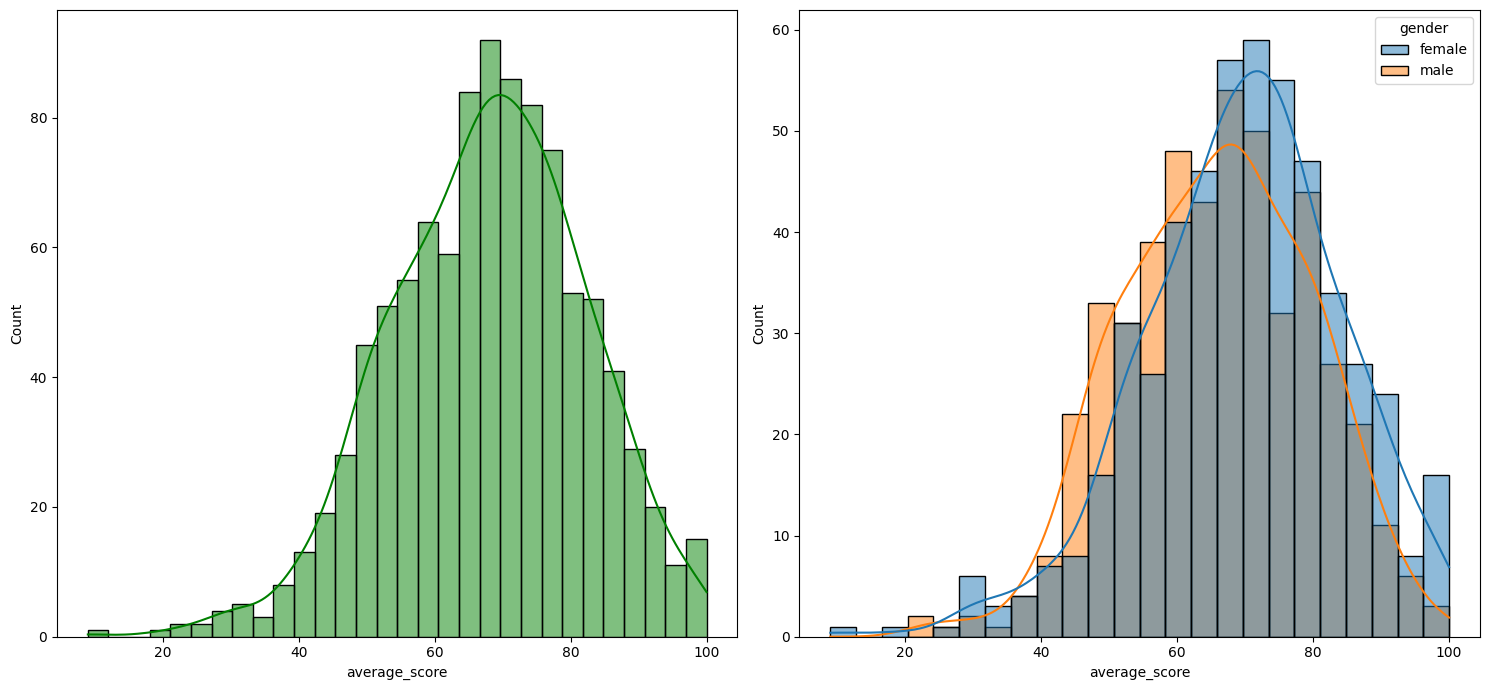

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Plot first histogram on the left subplot (ax=axs[0])
sns.histplot(
    data=df, 
    x='average_score', 
    bins=30, 
    kde=True, 
    color='g', 
    ax=axs[0]
)

# Plot second histogram on the right subplot (ax=axs[1])
sns.histplot(
    data=df, 
    x='average_score', 
    kde=True, 
    hue='gender', 
    ax=axs[1]
)

plt.tight_layout() # Ensures labels don't overlap


Females tends to perform well when it comes to results

C:\Users\bluem\AppData\Local\Temp\ipykernel_4696\1197049930.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(141)
C:\Users\bluem\AppData\Local\Temp\ipykernel_4696\1197049930.py:16: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(143)


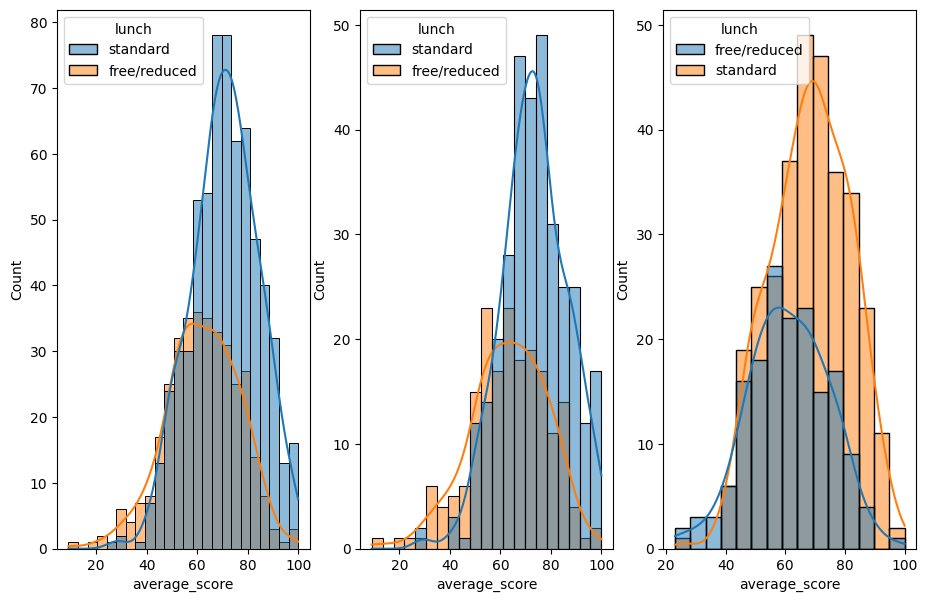

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(141)
sns.histplot(
    data=df, 
    x='average_score', 
    kde=True, 
    hue='lunch'
    
)
plt.subplot(142)
sns.histplot(
    data=df[df["gender"]=='female'], 
    x='average_score', 
    kde=True, 
    hue='lunch' )
plt.subplot(143)    
sns.histplot(
    data=df[df["gender"]=='male'], 
    x='average_score', 
    kde=True, 
    hue='lunch' )
plt.show()



Eating lunch has influenced the students performance 